<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #4f46e5; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Métricas de Evaluación en Clasificación y Regresión 📊🎯
      </h1>
      <p style="margin: 6px 0 0 0; color: #4f46e5; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Model Evaluation & Diagnostic
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #4338ca; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 02 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #4f46e5; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/02%20-%20Clasificacion%20y%20Regresion/04_Metricas_de_Evaluacion_en_Clasificacion_y_Regresion.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## Cierre del Módulo 02: de "qué tan bien predice" a "qué tan bien predice, y para qué" 🏁

Los Cuadernos 00-03 construyeron, en orden, los cimientos del aprendizaje supervisado (Cuaderno 00: sesgo-varianza, partición train/test, validación cruzada), el primer algoritmo no paramétrico (Cuaderno 01: k-NN), el primer modelo lineal para clasificación (Cuaderno 02: regresión logística) y su contraparte para regresión (Cuaderno 03: OLS, polinomial, Ridge/Lasso/ElasticNet). En los cuatro quedó una misma pregunta parcialmente sin responder: **¿son la accuracy y el R² suficientes para decir que un modelo es bueno?**

El Cuaderno 02 dejó el problema planteado de forma explícita: `LogisticRegression` sobre `transacciones_fraude.csv` alcanzó una accuracy altísima, pero también se advirtió que un clasificador trivial que siempre predijera "no fraude" ya obtendría 98.52% de accuracy sin detectar ni un solo caso -- sin resolver todavía *cómo* medir, de forma rigurosa, si un modelo realmente distingue la clase minoritaria. Este cuaderno cierra esa pregunta: construye el arsenal completo de métricas de clasificación (matriz de confusión, sensibilidad, especificidad, precisión, F1, ROC-AUC y PR-AUC) sobre ese mismo dataset, y el arsenal de métricas de regresión (MAE, RMSE, R²) sobre `inmuebles_precios.csv`, retomado del Cuaderno 03.

In [1]:
import os, sys, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "clientes_credito.csv": "...",
    "inmuebles_precios.csv": "...",
    "transacciones_fraude.csv": "...",
}

def load_dataset(filename: str) -> str:
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join("02 - Clasificacion y Regresion", "data", filename),
        os.path.join("Data Mining", "02 - Clasificacion y Regresion", "data", filename),
        os.path.join("..", "02 - Clasificacion y Regresion", "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/02%20-%20Clasificacion%20y%20Regresion/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        urllib.request.urlretrieve(url, target, timeout=3)
        return target
    except Exception:
        pass
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        return target
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
    precision_score, recall_score, f1_score, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    mean_absolute_error, mean_squared_error, r2_score,
)
import os
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

fraude = pd.read_csv(load_dataset("transacciones_fraude.csv"))
inmuebles = pd.read_csv(load_dataset("inmuebles_precios.csv"))

print(f"transacciones_fraude.csv -> {fraude.shape[0]} filas x {fraude.shape[1]} columnas")
print(f"inmuebles_precios.csv    -> {inmuebles.shape[0]} filas x {inmuebles.shape[1]} columnas")

# Reentrena el mismo flujo de clasificacion del Cuaderno 02 sobre transacciones_fraude.csv
feat_fraude = ["monto_transaccion", "tiempo_respuesta_ms", "intentos_previos"]
X_fraude = fraude[feat_fraude]
y_fraude = fraude["es_fraude"]

Xtr_f, Xte_f, ytr_f, yte_f = train_test_split(X_fraude, y_fraude, test_size=0.25, random_state=42, stratify=y_fraude)
scaler_f = StandardScaler().fit(Xtr_f)
Xtr_f_esc = scaler_f.transform(Xtr_f)
Xte_f_esc = scaler_f.transform(Xte_f)

clf_fraude = LogisticRegression(max_iter=1000, random_state=42).fit(Xtr_f_esc, ytr_f)
y_pred_05 = clf_fraude.predict(Xte_f_esc)
y_proba = clf_fraude.predict_proba(Xte_f_esc)[:, 1]

print(f"\nConjunto de prueba: {len(yte_f)} transacciones, {yte_f.sum()} fraudulentas ({yte_f.mean():.4%})")

transacciones_fraude.csv -> 4060 filas x 4 columnas
inmuebles_precios.csv    -> 1500 filas x 7 columnas

Conjunto de prueba: 1015 transacciones, 15 fraudulentas (1.4778%)


---
## 1. La Matriz de Confusión: los Cuatro Resultados Posibles 🧩

Para un clasificador binario, cada predicción sobre el conjunto de prueba cae en exactamente una de cuatro categorías, cruzando la clase real con la clase predicha:

| | Predicho: No Fraude (0) | Predicho: Fraude (1) |
|---|---|---|
| **Real: No Fraude (0)** | **TN** (Verdadero Negativo) | **FP** (Falso Positivo) |
| **Real: Fraude (1)** | **FN** (Falso Negativo) | **TP** (Verdadero Positivo) |

* **TP / TN (aciertos):** el modelo predijo correctamente.
* **FP (falso positivo o "falsa alarma"):** el modelo marcó como fraude una transacción legítima.
* **FN (falso negativo o "fraude escapado"):** el modelo dejó pasar una transacción que sí era fraudulenta -- en un escenario de fraude real, típicamente el error más costoso.

Toda métrica de clasificación de las Secciones 2-7 es, en el fondo, una forma distinta de resumir estos cuatro números.

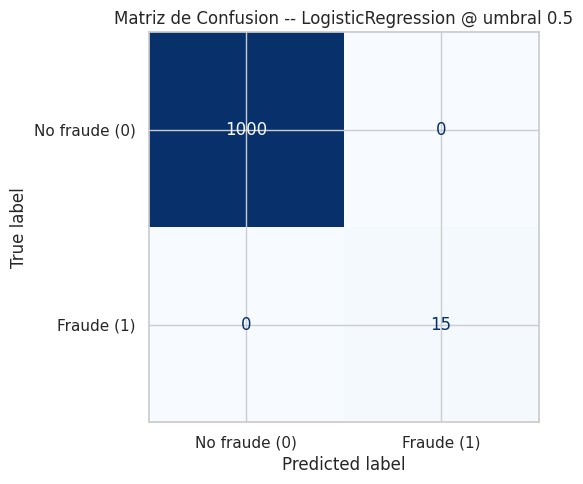

TN (verdaderos negativos) = 1000
FP (falsos positivos)     = 0
FN (falsos negativos)     = 0
TP (verdaderos positivos) = 15


In [2]:
cm = confusion_matrix(yte_f, y_pred_05)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No fraude (0)", "Fraude (1)"])
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Matriz de Confusion -- LogisticRegression @ umbral 0.5")
plt.tight_layout()
plt.show()

print(f"TN (verdaderos negativos) = {tn}")
print(f"FP (falsos positivos)     = {fp}")
print(f"FN (falsos negativos)     = {fn}")
print(f"TP (verdaderos positivos) = {tp}")

**Lectura:** sobre las 1015 transacciones del conjunto de prueba (15 fraudulentas, 1000 legítimas), la matriz de confusión da TN=1000, FP=0, FN=0, TP=15 -- el modelo clasifica correctamente **todas** las transacciones. Esto no es un error de cálculo: como ya se documentó en el Cuaderno 02, las tres variables de este dataset están construidas para separar casi perfectamente ambas clases (montos, tiempos de respuesta e intentos previos de fraude son órdenes de magnitud distintos a los de una transacción legítima). Es un caso favorable, pero **no** es la situación típica en producción -- y es precisamente el punto de partida de la siguiente sección: incluso con una matriz de confusión perfecta, hace falta preguntarse qué habría dicho la métrica más simple posible, la accuracy, si el modelo no hubiera sido bueno.

---
## 2. El Espejismo de la Accuracy: Clasificador Trivial vs. Modelo Real ⚠️

La accuracy ($=\frac{TP+TN}{TP+TN+FP+FN}$, la proporción de predicciones correctas) es la métrica más intuitiva y también la más fácil de inflar artificialmente cuando las clases están desbalanceadas. `es_fraude` tiene solo **1.4778%** de casos positivos (60 de 4060, Cuaderno 00) -- suficiente desbalance para que un clasificador que **no aprende absolutamente nada** obtenga una accuracy que suena, a primera vista, excelente.

In [3]:
y_trivial = np.zeros_like(yte_f)

acc_modelo = accuracy_score(yte_f, y_pred_05)
acc_trivial = accuracy_score(yte_f, y_trivial)
cm_trivial = confusion_matrix(yte_f, y_trivial)
recall_trivial = recall_score(yte_f, y_trivial, zero_division=0)

print(f"Accuracy del modelo LogisticRegression:           {acc_modelo:.4f}")
print(f"Accuracy de un clasificador trivial 'siempre 0':  {acc_trivial:.4f}")
print(f"\nMatriz de confusion del clasificador trivial:\n{cm_trivial}")
print(f"\nFraudes detectados por el clasificador trivial: {int(cm_trivial[1, 1])} de {int(yte_f.sum())}")
print(f"Recall del clasificador trivial: {recall_trivial:.4f}")

Accuracy del modelo LogisticRegression:           1.0000
Accuracy de un clasificador trivial 'siempre 0':  0.9852

Matriz de confusion del clasificador trivial:
[[1000    0]
 [  15    0]]

Fraudes detectados por el clasificador trivial: 0 de 15
Recall del clasificador trivial: 0.0000


**Lectura -- el pago de la promesa hecha en el Cuaderno 02:** un clasificador trivial que **siempre** predice "no fraude", sin mirar ni una sola variable, obtiene **98.52%** de accuracy sobre las 1015 transacciones de prueba -- y detecta **0 de 15** casos de fraude reales (recall = 0.0000). Frente a esa cifra, el 100% de accuracy del modelo real (Sección 1) parece apenas 1.48 puntos porcentuales mejor -- una diferencia que, mirada solo a través de la accuracy, parecería casi irrelevante. Pero en términos de la tarea real (detectar fraude), la diferencia es total: el clasificador trivial es completamente inútil (0% de fraude detectado) y el modelo real detecta el 100%. **La accuracy, por sí sola, no puede distinguir entre estos dos escenarios radicalmente distintos** -- exactamente la advertencia que el Cuaderno 02 dejó pendiente. Las Secciones 3-7 construyen las métricas que sí las distinguen.

---
## 3. Sensibilidad (Recall), Especificidad y Precisión: Más Allá de la Accuracy 🔬

Tres métricas, cada una una fracción distinta calculada sobre la matriz de confusión, responden preguntas de negocio distintas:

$$\text{Sensibilidad (Recall)} = \frac{TP}{TP+FN} \qquad \text{Especificidad} = \frac{TN}{TN+FP} \qquad \text{Precisión} = \frac{TP}{TP+FP}$$

* **Sensibilidad/Recall:** de todos los fraudes *reales*, ¿qué proporción detectó el modelo? Ignora por completo los TN -- es la métrica que expone justamente lo que la accuracy oculta (Sección 2): un modelo con recall=0 es inútil para detectar la clase positiva, sin importar cuántos TN acumule.
* **Especificidad:** de todas las transacciones *legítimas* reales, ¿qué proporción identificó correctamente el modelo como legítimas? Es el equivalente de recall pero para la clase negativa.
* **Precisión:** de todas las transacciones que el modelo *marcó* como fraude, ¿qué proporción realmente lo era? Responde "¿puedo confiar en una alerta de este modelo?", no "¿cuántos fraudes se me escaparon?" -- esa es la pregunta del recall.

In [4]:
recall_manual = tp / (tp + fn)
especificidad_manual = tn / (tn + fp)
precision_manual = tp / (tp + fp) if (tp + fp) > 0 else float("nan")

print(f"Sensibilidad/Recall = TP/(TP+FN) = {tp}/({tp}+{fn}) = {recall_manual:.4f}")
print(f"Especificidad       = TN/(TN+FP) = {tn}/({tn}+{fp}) = {especificidad_manual:.4f}")
print(f"Precision            = TP/(TP+FP) = {tp}/({tp}+{fp}) = {precision_manual:.4f}")

print("\nVerificacion con sklearn:")
print(f"recall_score    = {recall_score(yte_f, y_pred_05):.4f}")
print(f"precision_score = {precision_score(yte_f, y_pred_05):.4f}")

Sensibilidad/Recall = TP/(TP+FN) = 15/(15+0) = 1.0000
Especificidad       = TN/(TN+FP) = 1000/(1000+0) = 1.0000
Precision            = TP/(TP+FP) = 15/(15+0) = 1.0000

Verificacion con sklearn:
recall_score    = 1.0000
precision_score = 1.0000


**Lectura:** con la matriz de confusión perfecta de la Sección 1 (TN=1000, FP=0, FN=0, TP=15), las tres métricas dan el máximo posible: recall=1.0000 (los 15 fraudes fueron detectados), especificidad=1.0000 (las 1000 transacciones legítimas fueron correctamente identificadas como tales) y precisión=1.0000 (ninguna alerta del modelo fue una falsa alarma). En un caso real -- menos separable que este dataset diseñado para el curso -- **nunca se pueden maximizar recall y precisión simultáneamente sin límite**: forzar más recall (detectar más fraudes) típicamente exige aceptar más falsos positivos (menos precisión), y viceversa. Ese es el trade-off que se cuantifica en la Sección 4 moviendo el umbral de decisión.

---
## 4. El Trade-off Precisión-Recall: Moviendo el Umbral de Decisión 🎚️

`LogisticRegression.predict()` usa por defecto el umbral $\hat{p} \geq 0.5$ (Cuaderno 02, Sección 3) para decidir la clase. Ese umbral **no es obligatorio**: `predict_proba()` entrega la probabilidad continua, y cualquier umbral $u \in (0,1)$ define un clasificador distinto vía $\hat{y} = \mathbb{1}[\hat{p} \geq u]$.

* **Bajar el umbral** ($u < 0.5$): el modelo se vuelve más "agresivo" marcando fraude -- típicamente **sube el recall** (menos fraudes escapan) a costa de **más falsos positivos** (más alertas legítimas marcadas erróneamente, precisión más baja).
* **Subir el umbral** ($u > 0.5$): el modelo se vuelve más "conservador" -- típicamente **sube la precisión** (las alertas que sí emite son más confiables) a costa de **más falsos negativos** (más fraudes escapan, recall más bajo).

La siguiente celda barre 400 umbrales entre 0.0001 y 0.999, grafica cómo se mueven precisión y recall, y fija dos umbrales concretos para inspeccionar sus matrices de confusión.

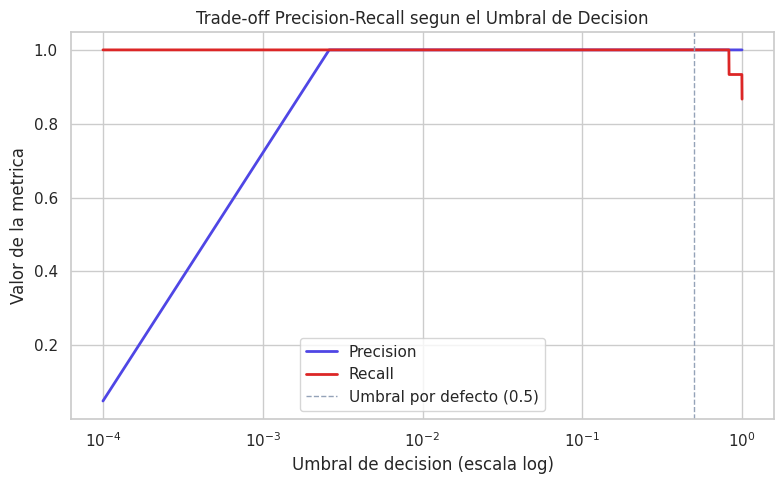

umbral=0.0005   TN= 982 FP= 18 FN= 0 TP=15  precision=0.4545  recall=1.0000
umbral=0.5      TN=1000 FP=  0 FN= 0 TP=15  precision=1.0000  recall=1.0000
umbral=0.999    TN=1000 FP=  0 FN= 2 TP=13  precision=1.0000  recall=0.8667


In [5]:
umbrales = np.linspace(0.0001, 0.999, 400)
precisiones, recalls = [], []
for u in umbrales:
    pred_u = (y_proba >= u).astype(int)
    precisiones.append(precision_score(yte_f, pred_u, zero_division=0))
    recalls.append(recall_score(yte_f, pred_u, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(umbrales, precisiones, color="#4f46e5", linewidth=2, label="Precision")
ax.plot(umbrales, recalls, color="#dc2626", linewidth=2, label="Recall")
ax.axvline(0.5, color="#94a3b8", linestyle="--", linewidth=1, label="Umbral por defecto (0.5)")
ax.set_xscale("log")
ax.set_xlabel("Umbral de decision (escala log)")
ax.set_ylabel("Valor de la metrica")
ax.set_title("Trade-off Precision-Recall segun el Umbral de Decision")
ax.legend()
plt.tight_layout()
plt.show()

for u in [0.0005, 0.5, 0.999]:
    pred_u = (y_proba >= u).astype(int)
    cm_u = confusion_matrix(yte_f, pred_u)
    tn_u, fp_u, fn_u, tp_u = cm_u.ravel()
    p_u = precision_score(yte_f, pred_u, zero_division=0)
    r_u = recall_score(yte_f, pred_u, zero_division=0)
    print(f"umbral={u:<8} TN={tn_u:4d} FP={fp_u:3d} FN={fn_u:2d} TP={tp_u:2d}  precision={p_u:.4f}  recall={r_u:.4f}")

**Lectura:** en este dataset en particular, el rango "seguro" de umbrales es inusualmente amplio -- entre aproximadamente 0.002 y 0.83, precisión y recall se mantienen ambos en 1.0000, porque la separación entre clases es casi perfecta (Sección 1). Fuera de ese rango, el trade-off aparece con toda claridad en las dos matrices de confusión concretas:

* **Umbral muy bajo (u=0.0005):** el recall se mantiene en 1.0000 (los 15 fraudes se siguen detectando), pero aparecen **18 falsos positivos** -- la precisión se desploma a **0.4545** (menos de la mitad de las alertas del modelo son fraude real). Aquí bajar el umbral no compró nada de recall adicional (ya estaba en el máximo) y solo costó precisión -- un umbral demasiado bajo sin beneficio.
* **Umbral muy alto (u=0.999):** la precisión se mantiene en 1.0000, pero el recall cae a **0.8667** -- **2 de los 15 fraudes** ahora pasan como falsos negativos. Aquí el modelo se volvió tan conservador que empezó a dejar escapar fraude real para no arriesgarse con ninguna alerta dudosa.

La lección general -- válida más allá de este dataset particular -- es que la elección del umbral es una **decisión de negocio**, no solo estadística: un banco que prioriza no perder ningún caso de fraude (FN muy costoso) elegirá un umbral bajo, aceptando más falsas alarmas; uno que prioriza no molestar a clientes legítimos con bloqueos innecesarios (FP muy costoso) elegirá un umbral alto, aceptando dejar pasar más fraude.

---
## 5. F1-Score: el Balance Armónico entre Precisión y Recall ⚖️

La Sección 4 mostró que precisión y recall se mueven en direcciones opuestas al cambiar el umbral -- ¿cómo resumir ambas en un solo número que sí penalice el desbalance entre ellas? El **F1-score** es la **media armónica** de precisión y recall:

$$F1 = 2 \cdot \frac{\text{Precisión} \cdot \text{Recall}}{\text{Precisión} + \text{Recall}}$$

A diferencia de la media aritmética, la media armónica castiga fuertemente cualquier valor bajo entre los dos: un modelo con precisión=1.0 y recall=0.0 (como el clasificador trivial de la Sección 2) obtiene F1=0.0, no F1=0.5 -- refleja que un extremo inútil arruina el balance, sin importar qué tan alto sea el otro extremo. Por esa razón, **F1 es preferible a accuracy cuando las clases están desbalanceadas** (exactamente el caso de `es_fraude`): accuracy puede quedar dominada por la clase mayoritaria, mientras que F1 exige que el modelo funcione razonablemente bien tanto en precisión como en recall sobre la clase de interés.

In [6]:
resumen_f1 = []
for u in [0.0005, 0.5, 0.999]:
    pred_u = (y_proba >= u).astype(int)
    resumen_f1.append({
        "umbral": u,
        "precision": precision_score(yte_f, pred_u, zero_division=0),
        "recall": recall_score(yte_f, pred_u, zero_division=0),
        "f1": f1_score(yte_f, pred_u, zero_division=0),
    })
resumen_f1.append({
    "umbral": "trivial (siempre 0)",
    "precision": precision_score(yte_f, y_trivial, zero_division=0),
    "recall": recall_score(yte_f, y_trivial, zero_division=0),
    "f1": f1_score(yte_f, y_trivial, zero_division=0),
})
tabla_f1 = pd.DataFrame(resumen_f1)
display(tabla_f1.round(4))

,umbral,precision,recall,f1
0,0.0005,0.4545,1.0000,0.6250
1,0.5000,1.0000,1.0000,1.0000
2,0.9990,1.0000,0.8667,0.9286
3,trivial (siempre 0),0.0000,0.0000,0.0000


**Lectura:** la tabla confirma la mecánica de la media armónica con los mismos tres umbrales de la Sección 4, más el clasificador trivial: en u=0.0005 (precisión=0.4545, recall=1.0000), F1=**0.6250** -- por debajo de cualquiera de los dos extremos, penalizando la precisión baja; en u=0.999 (precisión=1.0000, recall=0.8667), F1=**0.9286**; en el umbral por defecto (u=0.5), ambos son perfectos y F1=**1.0000**. El caso más revelador es el clasificador trivial: con accuracy=0.9852 (Sección 2) pero recall=0.0000, su F1 es **0.0000** -- un solo número que expone de inmediato que el modelo es inútil para la clase de interés, algo que la accuracy por sí sola nunca reveló.

---
## 6. Curva ROC y AUC: Rendimiento a Través de Todos los Umbrales 📈

En lugar de fijar un solo umbral, la curva **ROC** (*Receiver Operating Characteristic*) grafica, para **todos** los umbrales posibles, la Tasa de Verdaderos Positivos (TPR = Recall) contra la Tasa de Falsos Positivos ($FPR = \frac{FP}{FP+TN}$, el complemento de la especificidad):

$$TPR = \frac{TP}{TP+FN} \qquad FPR = \frac{FP}{FP+TN}$$

Un clasificador perfecto alcanza la esquina superior izquierda (TPR=1, FPR=0) para algún umbral; un clasificador aleatorio traza la diagonal $TPR=FPR$. El **AUC** (área bajo la curva ROC) resume la curva completa en un solo número entre 0 y 1: 0.5 equivale a azar, 1.0 a separación perfecta -- y, a diferencia de accuracy o F1, **no depende de elegir un umbral específico**, porque evalúa el modelo a través de todos ellos simultáneamente.

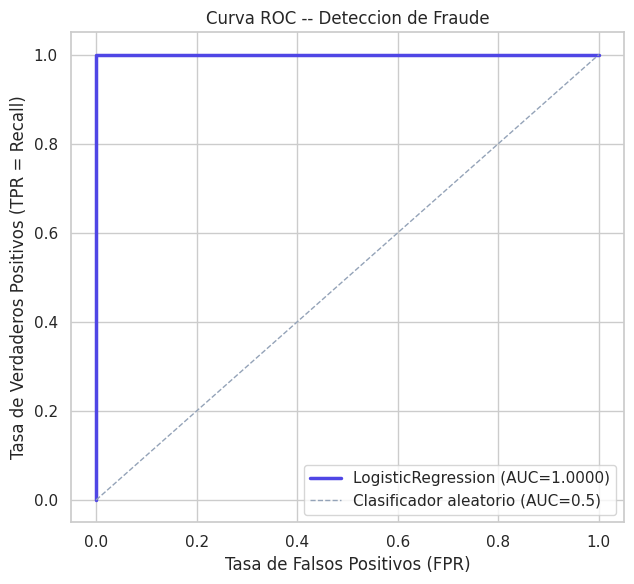

ROC-AUC: 1.0000


In [7]:
fpr, tpr, _ = roc_curve(yte_f, y_proba)
auc_roc = roc_auc_score(yte_f, y_proba)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(fpr, tpr, color="#4f46e5", linewidth=2.5, label=f"LogisticRegression (AUC={auc_roc:.4f})")
ax.plot([0, 1], [0, 1], color="#94a3b8", linestyle="--", linewidth=1, label="Clasificador aleatorio (AUC=0.5)")
ax.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR = Recall)")
ax.set_title("Curva ROC -- Deteccion de Fraude")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {auc_roc:.4f}")

**Lectura:** la curva alcanza la esquina superior izquierda casi de inmediato, y el AUC es **1.0000** -- separación perfecta entre las dos clases a través de todos los umbrales posibles, consistente con la matriz de confusión perfecta de la Sección 1. Un AUC de 1.0 es un resultado excelente, pero (como ya se advirtió en el Cuaderno 02 sobre la accuracy) conviene preguntarse si es *demasiado* bueno para ser la historia completa -- la Sección 7 muestra por qué ROC-AUC, específicamente en datos tan desbalanceados como este, puede seguir viéndose favorable incluso cuando el modelo empieza a fallar en la clase minoritaria.

---
## 7. La Otra Cara de ROC-AUC: PR-AUC en Datos Fuertemente Desbalanceados 🔎

El FPR de la curva ROC ($FP/(FP+TN)$) tiene en el denominador **TN** -- con 1000 transacciones legítimas en el conjunto de prueba frente a solo 15 fraudulentas, hacen falta *muchos* falsos positivos para que el FPR se mueva de forma apreciable. Esto puede hacer que ROC-AUC se vea **engañosamente alto** en problemas de evento raro, incluso cuando la precisión real del modelo (Sección 3) se está deteriorando.

La curva **Precision-Recall** y su área (**PR-AUC**, calculada con `average_precision_score`) no usan TN en absoluto -- solo TP, FP y FN -- por lo que son mucho más sensibles a cómo se comporta el modelo específicamente sobre la clase minoritaria. Es la alternativa recomendada para problemas de evento raro como este. Para exponer la diferencia con números reales (el modelo de este cuaderno es demasiado separable para mostrarla directamente), se simula -- únicamente con fines pedagógicos, sin alterar el dataset original -- una versión más ruidosa del mismo problema, agregando ruido gaussiano a las variables escaladas antes de reentrenar.

PR-AUC (Average Precision) del modelo real: 1.0000
ROC-AUC del modelo real:                    1.0000


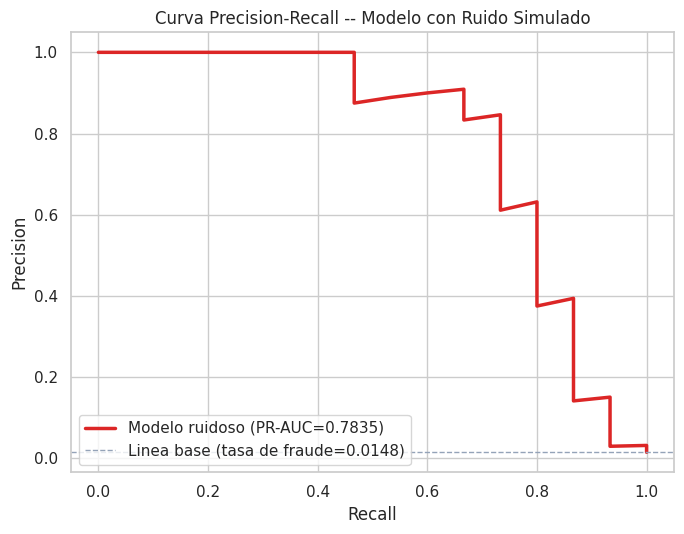


Modelo con ruido simulado -> ROC-AUC=0.9619   PR-AUC=0.7835


In [8]:
ap_clean = average_precision_score(yte_f, y_proba)
print(f"PR-AUC (Average Precision) del modelo real: {ap_clean:.4f}")
print(f"ROC-AUC del modelo real:                    {auc_roc:.4f}")

# Version deliberadamente ruidosa del mismo problema (solo con fines pedagogicos):
# se agrega ruido gaussiano sobre una COPIA de las variables ya escaladas.
# El dataset original (fraude, X_fraude, y_fraude) no se modifica en ningun momento.
rng = np.random.RandomState(42)
Xtr_ruido = Xtr_f_esc + rng.normal(0, 4, Xtr_f_esc.shape)
Xte_ruido = Xte_f_esc + rng.normal(0, 4, Xte_f_esc.shape)

clf_ruido = LogisticRegression(max_iter=1000, random_state=42).fit(Xtr_ruido, ytr_f)
proba_ruido = clf_ruido.predict_proba(Xte_ruido)[:, 1]

auc_roc_ruido = roc_auc_score(yte_f, proba_ruido)
ap_ruido = average_precision_score(yte_f, proba_ruido)

prec_curve, rec_curve, _ = precision_recall_curve(yte_f, proba_ruido)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(rec_curve, prec_curve, color="#dc2626", linewidth=2.5, label=f"Modelo ruidoso (PR-AUC={ap_ruido:.4f})")
ax.axhline(yte_f.mean(), color="#94a3b8", linestyle="--", linewidth=1, label=f"Linea base (tasa de fraude={yte_f.mean():.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall -- Modelo con Ruido Simulado")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"\nModelo con ruido simulado -> ROC-AUC={auc_roc_ruido:.4f}   PR-AUC={ap_ruido:.4f}")

**Lectura -- el límite honesto de ROC-AUC:** sobre el modelo real (sin ruido), ROC-AUC y PR-AUC coinciden en **1.0000** -- no hay divergencia posible cuando la separación es perfecta. Pero al simular una versión más ruidosa y realista del mismo problema, la divergencia aparece: **ROC-AUC=0.9619** sigue pareciendo un resultado sobresaliente, mientras que **PR-AUC=0.7835** revela una historia más matizada -- la precisión del modelo se degrada de forma mucho más visible al mirar solo la clase minoritaria. La brecha entre ambas cifras (≈0.18) es la advertencia central de esta sección: **en problemas de evento raro, un ROC-AUC alto no garantiza que el modelo funcione bien para el caso que realmente importa (detectar fraude)** -- siempre conviene revisar PR-AUC como complemento, no como sustituto, de ROC-AUC.

---
## 8. Guía de Selección de Métricas por Escenario de Negocio 🧭

| Escenario de negocio | Costo dominante | Métrica a priorizar | Ejemplo en este curso |
|---|---|---|---|
| Dejar pasar un fraude es muy costoso (pérdida económica, reputacional) | Falso Negativo (FN) alto | **Recall / Sensibilidad** (maximizar, aceptando más FP) | `transacciones_fraude.csv`: mejor bloquear de más que dejar pasar fraude. |
| Bloquear a un cliente legítimo es muy costoso (fricción, pérdida de confianza) | Falso Positivo (FP) alto | **Precisión** (maximizar, aceptando más FN) | Un sistema de alertas que, si se equivoca demasiado seguido, los analistas dejan de confiar en él. |
| Ambos costos son comparables y las clases están desbalanceadas | FN y FP con costo similar | **F1-score** | Comparar modelos candidatos sobre `riesgo_default` (Taller del módulo) sin una razón de negocio para priorizar uno u otro error. |
| Se necesita comparar modelos sin comprometerse aún a un umbral | -- | **ROC-AUC** (clases razonablemente balanceadas) o **PR-AUC** (clases raras, como `es_fraude`) | Seleccionar entre `LogisticRegression`, k-NN y árboles antes de decidir el umbral de producción. |
| Se reporta el desempeño a una audiencia no técnica | -- | **Accuracy**, siempre acompañada de al menos una métrica por clase | Nunca reportar accuracy sola en datos desbalanceados (Sección 2 de este cuaderno). |

---
## 9. Métricas de Regresión: MAE, RMSE y R² 📐

Con `precio_millones` (Cuaderno 03) no hay clases que confundir, sino un error numérico que cuantificar. Tres métricas resumen ese error de formas distintas:

$$MAE = \frac{1}{N}\sum_{i=1}^{N} |y_i - \hat{y}_i| \qquad RMSE = \sqrt{\frac{1}{N}\sum_{i=1}^{N} (y_i - \hat{y}_i)^2} \qquad R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

* **MAE** (Error Absoluto Medio): el promedio de los errores en valor absoluto, en las **unidades originales** de $y$ (millones de pesos). Trata cualquier error de la misma magnitud por igual, sin importar si viene de una sola observación muy errada o de muchas moderadamente erradas -- es **robusto a outliers**.
* **RMSE** (Raíz del Error Cuadrático Medio): también en unidades originales, pero **eleva al cuadrado antes de promediar** -- un error de 100 millones pesa 100 veces más que uno de 10 millones (no 10 veces más). Esto hace a RMSE **sensible a errores grandes/outliers**: penaliza desproporcionadamente a un modelo que se equivoca mucho en pocos casos, incluso si en promedio acierta bien.
* **R²**: la proporción de varianza de $y$ explicada por el modelo, ya usada en el Cuaderno 03 -- adimensional, fácil de comparar entre datasets distintos, pero puede ser engañoso con pocas variables o relaciones no lineales (un $R^2$ razonable no garantiza que el modelo esté bien especificado, como ya mostró el gráfico de residuos del Cuaderno 03).

In [9]:
feat_cols_inm = ["area_m2", "habitaciones", "estrato", "antiguedad_anios", "distancia_centro_km"]
X_inm = inmuebles[feat_cols_inm]
y_inm = inmuebles["precio_millones"]

Xtr_i, Xte_i, ytr_i, yte_i = train_test_split(X_inm, y_inm, test_size=0.25, random_state=42)

ols = LinearRegression().fit(Xtr_i, ytr_i)
pred_i = ols.predict(Xte_i)

mae = mean_absolute_error(yte_i, pred_i)
rmse = np.sqrt(mean_squared_error(yte_i, pred_i))
r2 = r2_score(yte_i, pred_i)

print(f"MAE  = {mae:.4f} millones")
print(f"RMSE = {rmse:.4f} millones")
print(f"R2   = {r2:.4f}")

residuos_i = yte_i - pred_i
peor_idx = residuos_i.abs().idxmax()
posicion_peor = list(Xte_i.index).index(peor_idx)

print(f"\nRMSE/MAE = {rmse / mae:.4f}")
print(f"Peor prediccion individual -> real={y_inm.loc[peor_idx]:.2f}  predicho={pred_i[posicion_peor]:.2f}  error={residuos_i.loc[peor_idx]:.2f} millones")

MAE  = 47.5260 millones
RMSE = 62.9638 millones
R2   = 0.8894

RMSE/MAE = 1.3248
Peor prediccion individual -> real=1249.89  predicho=879.17  error=370.72 millones


**Lectura:** reentrenando exactamente el mismo `LinearRegression` del Cuaderno 03 (Sección 1, mismas 5 variables y misma partición) sobre `inmuebles_precios.csv`, se obtiene **MAE=47.53 millones**, **RMSE=62.96 millones** y **R²=0.8894** -- coherente con lo ya reportado en el Cuaderno 03. La relación **RMSE/MAE=1.3248** confirma la sensibilidad de RMSE a errores grandes: si todos los errores fueran de la misma magnitud, ambas métricas coincidirían (razón=1.0); una razón mayor a 1 indica que unos pocos errores grandes están inflando el RMSE más de lo que inflan el MAE. El caso más extremo del conjunto de prueba lo ilustra: un inmueble con precio real de **1249.89 millones** fue predicho en **879.17 millones**, un error de **370.72 millones** -- un solo caso así, al elevarse al cuadrado dentro del RMSE, pesa mucho más que en el MAE. Esto conecta directamente con el diagnóstico de residuos del Cuaderno 03 (Sección 2): la correlación positiva entre $|\text{residuo}|$ y el valor predicho (0.1456) y el *skew* positivo (1.4667) ya anticipaban que el modelo comete sus errores más grandes en los inmuebles más caros -- justo el tipo de comportamiento que RMSE penaliza con más fuerza que MAE.

---
## 10. Tabla Comparativa: MAE vs. RMSE vs. R² 📋

| Métrica | Fórmula | Unidades | Sensibilidad a outliers | Cuándo preferirla |
|---|---|---|---|---|
| **MAE** | $\frac{1}{N}\sum \lvert y_i-\hat{y}_i \rvert$ | Las de $y$ (millones de pesos) | Baja -- cada error pesa proporcionalmente a su magnitud. | Se quiere una cifra interpretable y robusta, o el negocio no quiere que unos pocos casos extremos dominen la evaluación. |
| **RMSE** | $\sqrt{\frac{1}{N}\sum (y_i-\hat{y}_i)^2}$ | Las de $y$ (millones de pesos) | Alta -- el cuadrado amplifica errores grandes desproporcionadamente. | Los errores grandes son especialmente costosos en el negocio (p. ej. tasar un inmueble muy por debajo de su valor real). |
| **R²** | $1-\frac{\sum(y_i-\hat y_i)^2}{\sum(y_i-\bar y)^2}$ | Adimensional (0 a 1, puede ser negativo) | Indirecta -- depende de cómo los outliers afectan la varianza total y residual. | Comparar el ajuste relativo entre modelos o datasets distintos; siempre acompañado de MAE/RMSE para conocer la magnitud real del error. |

---
## 11. Ejercicio Práctico Guiado: `classification_report` en Dos Umbrales 📝

**Contexto:** la Sección 4 mostró que bajar el umbral de decisión de `LogisticRegression` sobre `transacciones_fraude.csv` puede introducir falsos positivos sin ganar recall adicional (ya estaba en el máximo). Vas a comprobarlo de forma completa usando `classification_report`, que resume precisión, recall y F1 por clase en una sola tabla.

**Tu misión:**
1. Genera las predicciones de clase al umbral por defecto (`u=0.5`) a partir de `y_proba` (ya calculado en la Sección 1 de este cuaderno).
2. Genera las predicciones de clase a un umbral más bajo (`u=0.001`).
3. Imprime `classification_report(yte_f, pred, target_names=["No fraude (0)", "Fraude (1)"], zero_division=0)` para cada uno de los dos umbrales.
4. Compara, para la clase "Fraude (1)", cómo cambian precisión y recall entre ambos umbrales.

In [10]:
### TU CÓDIGO AQUÍ ###
# 1. Predicciones de clase al umbral por defecto (0.5)
pred_u05 = None

# 2. Predicciones de clase a un umbral mas bajo (0.001)
pred_u001 = None

# 3. Imprime el classification_report para cada umbral
print("=== Umbral 0.5 ===")
# print(classification_report(...))

print("\n=== Umbral 0.001 ===")
# print(classification_report(...))

# 4. Escribe tu comparacion/conclusion aqui (como comentario o print)

=== Umbral 0.5 ===

=== Umbral 0.001 ===


<details>
<summary>💡 Ver solución propuesta</summary>

```python
pred_u05 = (y_proba >= 0.5).astype(int)
pred_u001 = (y_proba >= 0.001).astype(int)

print("=== Umbral 0.5 ===")
print(classification_report(yte_f, pred_u05, target_names=["No fraude (0)", "Fraude (1)"], zero_division=0))

print("\n=== Umbral 0.001 ===")
print(classification_report(yte_f, pred_u001, target_names=["No fraude (0)", "Fraude (1)"], zero_division=0))
```

Al umbral por defecto (0.5), la clase "Fraude (1)" tiene precisión=1.00 y recall=1.00. Al bajar el umbral a 0.001, el recall de "Fraude (1)" se mantiene en 1.00 (no se ganó nada -- ya se detectaban los 15 casos), pero su precisión cae a 0.88 -- el modelo empieza a marcar transacciones legítimas como fraude sin ningún beneficio adicional en detección. Conclusión: bajar el umbral por debajo del punto donde el recall ya es máximo solo introduce falsos positivos, sin mejorar la detección real de fraude -- el mismo patrón que la Sección 4 mostró con la matriz de confusión, ahora confirmado con `classification_report`.

</details>

---
## 12. Resumen Ejecutivo del Módulo 02: el Recorrido Completo 📌

1. **El Cuaderno 00** estableció los cimientos: el dilema sesgo-varianza, por qué nunca se evalúa sobre datos de entrenamiento, la estratificación (`stratify=y`) como requisito en datos desbalanceados y la validación cruzada como forma de estimar el desempeño real más allá de una sola partición.
2. **El Cuaderno 01** aplicó esos cimientos al primer algoritmo, k-NN, mostrando que escalar las variables no es opcional (accuracy 0.5067→0.7100 sobre `clientes_credito.csv`) y que $k$ controla su propio dilema sesgo-varianza.
3. **El Cuaderno 02** introdujo el primer modelo lineal para clasificación, regresión logística, vía odds/log-odds y la sigmoide, y dejó planteada -- pero no resuelta -- la pregunta de este cuaderno: ¿es la accuracy suficiente en `transacciones_fraude.csv` (1.4778% de fraude)?
4. **El Cuaderno 03** hizo el mismo recorrido para regresión: OLS, regresión polinomial (y su propio riesgo de sobreajuste) y regularización Ridge/Lasso/ElasticNet sobre `inmuebles_precios.csv`, alcanzando $R^2$≈0.89-0.99 según la configuración.
5. **Este cuaderno (04) cierra el círculo:** un clasificador trivial "siempre no-fraude" obtiene 98.52% de accuracy sin detectar ningún fraude (recall=0.0000) -- la prueba concreta de que accuracy sola es insuficiente en datos desbalanceados. Sensibilidad, especificidad, precisión y F1 exponen lo que accuracy oculta; el trade-off precisión-recall vía el umbral de decisión (u=0.0005 → precisión 0.4545; u=0.999 → recall 0.8667) convierte la elección de umbral en una decisión de negocio explícita; y PR-AUC (0.7835 en la variante ruidosa) expone lo que ROC-AUC (0.9619 en esa misma variante) puede ocultar en problemas de evento raro.
6. **En regresión, MAE (47.53M), RMSE (62.96M) y R² (0.8894) sobre `inmuebles_precios.csv`** cuantifican tipos de error distintos -- RMSE penaliza desproporcionadamente al peor caso del conjunto de prueba (error de 370.72M en un solo inmueble), mientras que MAE lo trata proporcionalmente a su magnitud.
7. **La historia completa del módulo:** ningún modelo, por sí solo, es "bueno" o "malo" -- lo es únicamente en relación con la métrica (y el escenario de negocio) con el que se evalúa. La Sección 8 de este cuaderno resume esa correspondencia; en la práctica, la elección de métrica es tan parte del trabajo del científico de datos como la elección del modelo.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | Clasificación y Regresión</i>
  </p>
</div>